# **AA1 Competition Project**

This notebook builds the preprocessing pipeline for the Wi-Fi CSI localization problem.

The objective is to transform the raw dataset into useful feature matrices for later classification models.  
The pipeline includes:

1. Exploratory Data Analysis (EDA)
2. Identification of inactive OFDM subcarriers
3. Removal of non-informative features
4. CSI feature engineering from raw I/Q values
5. Sanity checks
6. Scaling
7. Saving the processed datasets

#### Imports

In [2]:
pip install seaborn
pip install scikit-learn

SyntaxError: invalid syntax (3849909237.py, line 1)

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
import pickle
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.precision", 3)
pd.set_option("display.max_columns", 30)

## **1. Exploratory Data Analysis (EDA)**

### **1.1 Dataset overview**

In [5]:
# The CSV files use semicolon separators.
# The first column is the row ID, so we use it as index.
train = pd.read_csv("train_nt.csv", sep=";", index_col=0)
test  = pd.read_csv("test_nolabels_nt.csv", sep=";", index_col=0)

print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")

Train shape: (12888, 261)
Test shape:  (3223, 260)


The training dataset contains 261 columns, including the target variable position, while the test dataset contains 260 columns, since the labels are not provided and must be predicted.Reflexio


In [6]:
train.head(3)

,seq_ctrl,aoa,rssi1,rssi2,I0_1,Q0_1,I1_1,Q1_1,I2_1,Q2_1,I3_1,Q3_1,I4_1,Q4_1,I5_1,...,I57_2,Q57_2,I58_2,Q58_2,I59_2,Q59_2,I60_2,Q60_2,I61_2,Q61_2,I62_2,Q62_2,I63_2,Q63_2,position
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0,-5703,-88,-88,0,0,4,5,7,8,5,4,6,3,8,...,10,-9,10,-13,6,-13,6,-13,-2,-8,3,-12,1,-12,9
1,0,1835,-91,-88,0,0,-10,4,-7,3,-10,7,-8,7,-3,...,-11,-8,-8,-5,-8,-7,-11,-9,-18,-7,-8,-8,-8,-10,9
2,0,4,-86,-87,0,0,5,14,5,5,6,14,5,15,13,...,7,9,4,11,8,10,7,16,7,13,11,16,11,13,9


### **1.2 Separate features and target**

In [9]:
X_train_raw = train.drop(columns=["position"])
y_train = train["position"].astype(int)

X_test_raw = test.copy()

print("X_train_raw:", X_train_raw.shape)
print("y_train:    ", y_train.shape)
print("X_test_raw: ", X_test_raw.shape)

X_train_raw: (12888, 260)
y_train:     (12888,)
X_test_raw:  (3223, 260)


The dataset was split into input features X and target labels y, where the column position represents the class to be predicted. This column was removed from the feature matrix to avoid data leakage. This separation allows the model to learn a mapping from the observed features to the device position.

### **1.3 Basic data inspection**

In [10]:
print("Data types:")
print(train.dtypes.value_counts())

print("\nMissing values:")
print("Train NaN:", train.isnull().sum().sum())
print("Test NaN: ", test.isnull().sum().sum())

Data types:
int64    261
Name: count, dtype: int64

Missing values:
Train NaN: 0
Test NaN:  0


All features are numeric (int64), which allows direct use in machine learning models without encoding. Additionally, no missing values were found in either the training or test datasets, so no imputation was required.

### **1.4 Target distribution**

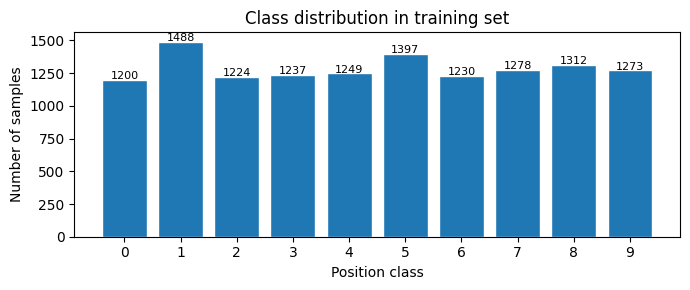

position
0    1200
1    1488
2    1224
3    1237
4    1249
5    1397
6    1230
7    1278
8    1312
9    1273
Name: count, dtype: int64


In [11]:
fig, ax = plt.subplots(figsize=(7, 3))

counts = y_train.value_counts().sort_index()
ax.bar(counts.index, counts.values, edgecolor="white")
ax.set_xlabel("Position class")
ax.set_ylabel("Number of samples")
ax.set_title("Class distribution in training set")
ax.set_xticks(range(10))

for i, v in enumerate(counts.values):
    ax.text(i, v + 5, str(v), ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("fig_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(counts)

The class distribution is **approximately balanced**, with a similar number of samples for each class. Therefore, no specific techniques for handling class imbalance were required.


### **1.5 Feature analysis**

#### 1.5.1 Non-CSI Features

In [12]:
train[["seq_ctrl", "aoa", "rssi1", "rssi2"]].describe()

,seq_ctrl,aoa,rssi1,rssi2
count,12888.000,12888.000,12888.000,12888.000
mean,16008.410,15.017,-78.052,-77.952
std,19829.509,3087.311,6.805,8.349
min,0.000,-8703.000,-97.000,-94.000
25%,0.000,-1751.000,-83.000,-84.000
50%,5464.000,-30.000,-80.000,-80.000
75%,29424.000,1798.000,-74.000,-71.000
max,65520.000,8915.000,-58.000,-58.000


Observations:

- `seq_ctrl` is a packet sequence counter, not a physical localization feature.
- `aoa` is related to the estimated angle of arrival.
- `rssi1` and `rssi2` measure received signal strength at the two antennas.
- The RSSI values are useful because closer positions should usually have stronger received power.

The non-CSI features (seq_ctrl, aoa, rssi1, rssi2) show different statistical properties. The **RSSI** values are within a reasonable range (around -80 dBm), providing meaningful signal strength information. The **aoa** feature presents a very large variance and extreme values, indicating that it may require normalization before being used. The **seq_ctrl** feature behaves as a sequence counter and is not expected to provide useful information for classification.

#### 1.5.2 CSI feature structure

CSI captures the effect of the wireless channel on the transmitted signal, including multipath propagation and fading, which makes it highly informative for localization tasks.

Each sample contains raw Channel State Information (CSI) measurements from two antennas. For each antenna, 64 OFDM subcarriers are recorded, and each subcarrier is represented by two values: the in-phase (I) and quadrature (Q) components. Therefore, each sample includes 256 CSI-related features (64 subcarriers × 2 components × 2 antennas). These values correspond to the complex representation of the wireless channel.

In [13]:
csi_cols = X_train_raw.columns[4:]  # after seq_ctrl, aoa, rssi1, rssi2

print("Number of CSI columns:", len(csi_cols))
print("First CSI columns:", list(csi_cols[:10]))
print("Last CSI columns: ", list(csi_cols[-10:]))

Number of CSI columns: 256
First CSI columns: ['I0_1', 'Q0_1', 'I1_1', 'Q1_1', 'I2_1', 'Q2_1', 'I3_1', 'Q3_1', 'I4_1', 'Q4_1']
Last CSI columns:  ['I59_2', 'Q59_2', 'I60_2', 'Q60_2', 'I61_2', 'Q61_2', 'I62_2', 'Q62_2', 'I63_2', 'Q63_2']


Since CSI is represented in terms of I/Q components, it may be beneficial to transform these values into amplitude and phase representations, which are more interpretable from a physical perspective.
Additionally, not all subcarriers carry useful information, as some correspond to guard bands or DC components. These will be analyzed and potentially removed in later stages.

In particular, phase differences between antennas are expected to be highly informative for localization, as they encode spatial information about the signal propagation.

## **2. Preprocessing and Feature Engineering**

### **2.1 Identify inactive subcarriers**

Each CSI sample contains complex measurements for 64 OFDM subcarriers at two receiving antennas. However, in an OFDM Wi-Fi signal, not all subcarriers are used to carry useful channel information. Some subcarriers are reserved as DC/null or guard subcarriers and therefore remain constant, typically equal to zero, across all samples.

Since a machine learning classifier can only exploit features that vary between samples or classes, constant features do not provide any discriminative information. Keeping them in the dataset increases the dimensionality without adding useful information and may make the learning process less efficient. For this reason, we identified subcarriers whose I/Q components had zero variance across the training set and removed the corresponding columns from both the training and test sets.

In [14]:
zero_sub = []
active_sub = []

for n in range(64):
    cols = [f"I{n}_1", f"Q{n}_1", f"I{n}_2", f"Q{n}_2"]
    stds = X_train_raw[cols].std()

    if np.all(np.isclose(stds, 0)):
        zero_sub.append(n)
    else:
        active_sub.append(n)

print(f"Zero-variance subcarrier indices: {zero_sub}")
print(f"Active subcarrier indices ({len(active_sub)}): {active_sub}")

Zero-variance subcarrier indices: [0, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37]
Active subcarrier indices (52): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63]



These inactive subcarriers correspond to DC/null/guard subcarriers. They are constant and do not help classification.

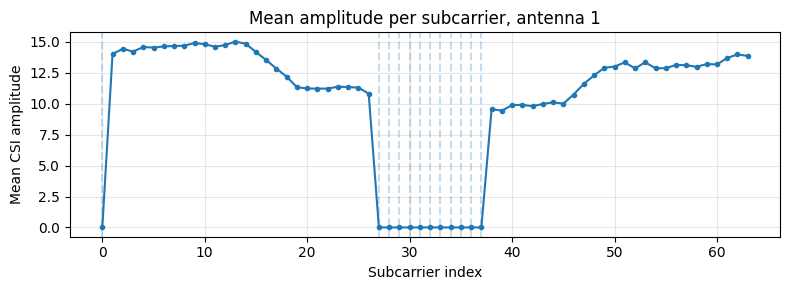

In [15]:
mean_amplitude_all = []

for n in range(64):
    I = X_train_raw[f"I{n}_1"].values
    Q = X_train_raw[f"Q{n}_1"].values
    mean_amplitude_all.append(np.sqrt(I**2 + Q**2).mean())

plt.figure(figsize=(8, 3))
plt.plot(range(64), mean_amplitude_all, marker="o", markersize=3)

for n in zero_sub:
    plt.axvline(n, linestyle="--", alpha=0.25)

plt.xlabel("Subcarrier index")
plt.ylabel("Mean CSI amplitude")
plt.title("Mean amplitude per subcarrier, antenna 1")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("fig_zero_subcarriers.png", dpi=150, bbox_inches="tight")
plt.show()

In the training set, subcarrier 0 and subcarriers 27–37 showed zero variance across all samples and antennas. These subcarriers correspond to inactive DC/null/guard components and do not provide discriminative information. Therefore, the derived features associated with these 12 subcarriers were removed from the final feature matrix. 

#### 2.1.1 Drop non-informative raw features

In [16]:
def drop_non_informative(df, zero_subcarriers):
    """Drop seq_ctrl and all I/Q columns belonging to inactive subcarriers."""
    cols_to_drop = ["seq_ctrl"]

    for n in zero_subcarriers:
        for ant in [1, 2]:
            cols_to_drop += [f"I{n}_{ant}", f"Q{n}_{ant}"]

    cols_to_drop = [c for c in cols_to_drop if c in df.columns]
    return df.drop(columns=cols_to_drop)

X_train_clean_raw = drop_non_informative(X_train_raw, zero_sub)
X_test_clean_raw  = drop_non_informative(X_test_raw, zero_sub)

print("X_train_clean_raw:", X_train_clean_raw.shape)
print("X_test_clean_raw: ", X_test_clean_raw.shape)

X_train_clean_raw: (12888, 211)
X_test_clean_raw:  (3223, 211)



- Original features: 260
- Remove `seq_ctrl`: −1
- Remove 12 inactive subcarriers × 2 antennas × 2 I/Q components: −48

Final number:

```text
260 - 1 - 48 = 211
```

Since each subcarrier is represented by four I/Q features, two per antenna, this step removed 48 constant features from the original dataset.

### **2.3 CSI transformation: I/Q to amplitude, phase, phase difference and amplitude ratio**

In [ ]:
def engineer_csi_features(df, active_subcarriers):
    """
    Build physically meaningful CSI features:
    - amplitude per antenna
    - phase per antenna
    - inter-antenna phase difference
    - amplitude ratio between antennas

    Keeps: aoa, rssi1, rssi2, rssi_diff.
    Drops raw I/Q components.
    """
    new_df = pd.DataFrame(index=df.index)

    # Base non-CSI features
    new_df["aoa"] = df["aoa"]
    new_df["rssi1"] = df["rssi1"]
    new_df["rssi2"] = df["rssi2"]
    new_df["rssi_diff"] = df["rssi1"] - df["rssi2"]

    eps = 1e-6

    for n in active_subcarriers:
        I1 = df[f"I{n}_1"].values.astype(float)
        Q1 = df[f"Q{n}_1"].values.astype(float)
        I2 = df[f"I{n}_2"].values.astype(float)
        Q2 = df[f"Q{n}_2"].values.astype(float)

        amp1 = np.sqrt(I1**2 + Q1**2)
        amp2 = np.sqrt(I2**2 + Q2**2)

        phase1 = np.arctan2(Q1, I1)
        phase2 = np.arctan2(Q2, I2)

        # Wrapped phase difference in [-pi, pi]
        dphi = np.angle(np.exp(1j * (phase1 - phase2)))

        new_df[f"amp{n}_1"] = amp1
        new_df[f"amp{n}_2"] = amp2
        new_df[f"phase{n}_1"] = phase1
        new_df[f"phase{n}_2"] = phase2
        new_df[f"dphi{n}"] = dphi
        new_df[f"aratio{n}"] = amp1 / (amp2 + eps)

    return new_df

X_train_eng = engineer_csi_features(X_train_clean_raw, active_sub)
X_test_eng  = engineer_csi_features(X_test_clean_raw, active_sub)

print("X_train_eng:", X_train_eng.shape)
print("X_test_eng: ", X_test_eng.shape)

print("\nFeature count explanation:")
print("Base features: 4")
print(f"CSI engineered features: {len(active_sub)} active subcarriers × 6 = {len(active_sub) * 6}")
print(f"Total: {4 + len(active_sub) * 6}")

**Expected output:**

```text
X_train_eng: (12888, 316)
X_test_eng:  (3223, 316)
```

Why 316?

```text
4 base features + 52 active subcarriers × 6 engineered CSI features = 316
```

The six CSI features per active subcarrier are:

1. `amp_n_1`
2. `amp_n_2`
3. `phase_n_1`
4. `phase_n_2`
5. `dphi_n`
6. `aratio_n`

### **2.4 Sanity checks after feature engineering**

In [ ]:
print("NaN in engineered train:", X_train_eng.isnull().sum().sum())
print("NaN in engineered test: ", X_test_eng.isnull().sum().sum())

print("Inf in engineered train:", np.isinf(X_train_eng.values).sum())
print("Inf in engineered test: ", np.isinf(X_test_eng.values).sum())

print("\nFirst engineered columns:")
print(X_train_eng.columns[:15].tolist())

**Expected output:**

```text
NaN in engineered train: 0
NaN in engineered test:  0
Inf in engineered train: 0
Inf in engineered test:  0
```

If this is not zero, the feature engineering step must be fixed before training models.

## **3. Exploratory Analysis on Engineered Features**

### **3.1 RSSI per class**

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, feat in zip(axes, ["rssi1", "rssi2"]):
    data_per_class = [X_train_eng.loc[y_train == c, feat].values for c in range(10)]
    ax.boxplot(data_per_class, labels=range(10), patch_artist=True)
    ax.set_xlabel("Position class")
    ax.set_ylabel("RSSI (dBm)")
    ax.set_title(feat)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("RSSI distribution per class")
plt.tight_layout()
plt.savefig("fig_rssi_per_class.png", dpi=150, bbox_inches="tight")
plt.show()

### **3.2 CSI amplitude profiles per class**

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ant_idx, ant in enumerate([1, 2]):
    ax = axes[ant_idx]

    for pos in range(10):
        subset = train[train["position"] == pos]
        amps = []

        for n in range(64):
            I = subset[f"I{n}_{ant}"].values
            Q = subset[f"Q{n}_{ant}"].values
            amps.append(np.sqrt(I**2 + Q**2).mean())

        ax.plot(range(64), amps, alpha=0.8, label=f"pos {pos}")

    ax.set_xlabel("Subcarrier index")
    ax.set_ylabel("Mean CSI amplitude")
    ax.set_title(f"Antenna {ant}")
    ax.legend(fontsize=6, ncol=2)

plt.suptitle("Mean CSI amplitude per subcarrier and position")
plt.tight_layout()
plt.savefig("fig_csi_amplitude_profile.png", dpi=150, bbox_inches="tight")
plt.show()

### **3.3 Phase difference per class**

In [ ]:
sample_subs = [1, 5, 10, 20, 45, 60]
fig, axes = plt.subplots(2, 3, figsize=(13, 7))

for ax, n in zip(axes.flat, sample_subs):
    if n in active_sub:
        data = [X_train_eng.loc[y_train == c, f"dphi{n}"].values for c in range(10)]
        ax.boxplot(data, labels=range(10), patch_artist=True)
        ax.set_title(f"dphi subcarrier {n}")
        ax.set_xlabel("Position class")
        ax.set_ylabel("Phase difference (rad)")
        ax.grid(axis="y", alpha=0.3)
    else:
        ax.axis("off")

plt.suptitle("Inter-antenna phase difference per class")
plt.tight_layout()
plt.savefig("fig_dphi_per_class.png", dpi=150, bbox_inches="tight")
plt.show()

### **3.4 Correlation with target**

In [ ]:
corr_with_target = X_train_eng.copy()
corr_with_target["position"] = y_train.values

target_corr = (
    corr_with_target
    .corr(numeric_only=True)["position"]
    .drop("position")
    .abs()
    .sort_values(ascending=False)
)

print("Top 20 features by absolute Pearson correlation with position:")
print(target_corr.head(20))

top30 = target_corr.head(30)

plt.figure(figsize=(10, 6))
plt.barh(top30.index[::-1], top30.values[::-1])
plt.xlabel("|Pearson correlation| with position")
plt.title("Top 30 engineered features by correlation with target")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("fig_feature_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

This is not a definitive feature selection method, because the target is categorical and the relationship may be non-linear.  
However, it is useful for identifying which engineered features show a first-order relationship with the label.

## **4. Scaling**

In [ ]:
scaler_eng = StandardScaler()

X_train_eng_scaled = pd.DataFrame(
    scaler_eng.fit_transform(X_train_eng),
    columns=X_train_eng.columns,
    index=X_train_eng.index
)

X_test_eng_scaled = pd.DataFrame(
    scaler_eng.transform(X_test_eng),
    columns=X_test_eng.columns,
    index=X_test_eng.index
)

print("X_train_eng_scaled:", X_train_eng_scaled.shape)
print("X_test_eng_scaled: ", X_test_eng_scaled.shape)

print("Mean check:", X_train_eng_scaled.mean().abs().mean().round(6))
print("Std check: ", X_train_eng_scaled.std().mean().round(6))

**Expected output:**

```text
X_train_eng_scaled: (12888, 316)
X_test_eng_scaled:  (3223, 316)
Mean check: approximately 0
Std check: approximately 1
```

The scaler is fitted only on the training set and then applied to the test set. This avoids data leakage.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

X_train_eng["rssi1"].hist(bins=40, ax=axes[0])
axes[0].set_title("rssi1 before scaling")

X_train_eng_scaled["rssi1"].hist(bins=40, ax=axes[1])
axes[1].set_title("rssi1 after StandardScaler")

plt.tight_layout()
plt.savefig("fig_scaling_example.png", dpi=150, bbox_inches="tight")
plt.show()

## **5. Alternative raw I/Q dataset**

In [ ]:
# Some models, especially tree-based models, may also work well with raw I/Q features.
# Here we save a cleaned raw version: seq_ctrl and inactive subcarriers removed.

scaler_raw = StandardScaler()

X_train_raw_scaled = pd.DataFrame(
    scaler_raw.fit_transform(X_train_clean_raw),
    columns=X_train_clean_raw.columns,
    index=X_train_clean_raw.index
)

X_test_raw_scaled = pd.DataFrame(
    scaler_raw.transform(X_test_clean_raw),
    columns=X_test_clean_raw.columns,
    index=X_test_clean_raw.index
)

print("X_train_clean_raw:", X_train_clean_raw.shape)
print("X_test_clean_raw: ", X_test_clean_raw.shape)
print("X_train_raw_scaled:", X_train_raw_scaled.shape)
print("X_test_raw_scaled: ", X_test_raw_scaled.shape)

**Expected output:**

```text
X_train_clean_raw: (12888, 211)
X_test_clean_raw:  (3223, 211)
X_train_raw_scaled: (12888, 211)
X_test_raw_scaled:  (3223, 211)
```

## **6. Save processed files**

In [ ]:
# Main engineered feature set
X_train_eng_scaled.to_csv("X_train_eng_scaled.csv")
X_test_eng_scaled.to_csv("X_test_eng_scaled.csv")

# Engineered but unscaled version, useful for tree-based models
X_train_eng.to_csv("X_train_eng.csv")
X_test_eng.to_csv("X_test_eng.csv")

# Clean raw I/Q versions
X_train_raw_scaled.to_csv("X_train_raw_scaled.csv")
X_test_raw_scaled.to_csv("X_test_raw_scaled.csv")

# Labels
y_train.to_csv("y_train.csv", header=True)

# Objects needed to reproduce preprocessing
with open("scaler_eng.pkl", "wb") as f:
    pickle.dump(scaler_eng, f)

with open("scaler_raw.pkl", "wb") as f:
    pickle.dump(scaler_raw, f)

with open("active_subcarriers.pkl", "wb") as f:
    pickle.dump(active_sub, f)

with open("zero_subcarriers.pkl", "wb") as f:
    pickle.dump(zero_sub, f)

print("Files saved successfully.")
print()
print("Generated files:")
print("- X_train_eng_scaled.csv")
print("- X_test_eng_scaled.csv")
print("- X_train_eng.csv")
print("- X_test_eng.csv")
print("- X_train_raw_scaled.csv")
print("- X_test_raw_scaled.csv")
print("- y_train.csv")
print("- scaler_eng.pkl")
print("- scaler_raw.pkl")
print("- active_subcarriers.pkl")
print("- zero_subcarriers.pkl")

## **7. Preprocessing summary**

| Step | Train shape | Test shape | Meaning |
|---|---:|---:|---|
| Raw features | `(12888, 260)` | `(3223, 260)` | Original data without label |
| Clean raw I/Q | `(12888, 211)` | `(3223, 211)` | Removed `seq_ctrl` and inactive subcarriers |
| Engineered CSI | `(12888, 316)` | `(3223, 316)` | Added amplitude, phase, phase difference and amplitude ratio |
| Scaled engineered CSI | `(12888, 316)` | `(3223, 316)` | Ready for SVM, KNN, logistic regression, MLP |

Main decisions:

- `seq_ctrl` was removed because it is a sequence counter.
- Inactive subcarriers `[0, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37]` were removed.
- Raw I/Q CSI was transformed into physically interpretable features.
- `StandardScaler` was fitted only on the training set.
- Both engineered and raw-clean versions were saved for later model comparison.